# PatchTST RevIN price forecasting -- directional loss weight sweep on step 3b

**Follow-up to `hf_patchtst_revin_ohlc_global_volume_dirloss`**, whose first pass at
`DIR_LOSS_WEIGHT=0.1` was an essentially null result -- directional accuracy unchanged
within noise (0.467-0.482 vs. 0.464-0.480 without the term), `channel_attention=False`'s
coherence actually dropped. That result only ruled out weight=0.1, not the directional-loss
approach itself -- most likely 0.1 was too small to meaningfully compete with the MSE term.

**This notebook sweeps `DIR_LOSS_WEIGHT` over `[0.5, 1.0, 3.0]`, crossed with both
`channel_attention` settings -- 6 training runs in one pass.** `DIR_LOSS_SCALE` stays fixed
at `1.0` (not swept this round -- see caveats).

Same directional loss as before: `-log(sigmoid(DIR_LOSS_SCALE * pred_ret * true_ret))`,
`pred_ret`/`true_ret` measured relative to `close_0` (the same anchor
`directional_accuracy` is measured against), total loss = `mse + DIR_LOSS_WEIGHT * dir_loss`.
Same underlying architecture/data/RevIN-OHLC+global-volume normalization as
`hf_patchtst_revin_ohlc_global_volume` (checked out from its exact commit, `f1ad007`).

**What to look for**: does directional accuracy move meaningfully above the ~0.46-0.48
band as `DIR_LOSS_WEIGHT` increases, and if so, at what cost to OHLC RMSE? A weight where
direction crosses back above 0.50 without RMSE blowing up would be the first sign this
approach can rescue the volume-included variant; if direction stays flat even at
`DIR_LOSS_WEIGHT=3.0` (30x the original), that's much stronger evidence the mechanism
doesn't work here at all, not just that 0.1 was too small.

**Deferred, same as every other notebook in this family**: the long-only bracket-order
backtest, until a target/volume/loss combination is picked.


## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "patchtst_ohlcv_mse"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    #
    # fetch + checkout {BRANCH} (not just `pull`): REPO_DIR persists across notebook runs
    # within the same Colab VM session, so if an earlier run in this session cloned a
    # DIFFERENT branch (e.g. this VM was previously used for a notebook with an older
    # BRANCH value), a bare `pull` here would just pull more commits onto that stale
    # branch instead of switching -- and the push cell at the bottom would then fail with
    # "src refspec {BRANCH} does not match any", since no local branch by that name would
    # exist to push. Explicitly checking out BRANCH every time this cell runs avoids that.
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} checkout {BRANCH}
    !git -C {REPO_DIR} pull origin {BRANCH}

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}


remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 91.42 KiB | 1.63 MiB/s, done.
From https://github.com/WoodyChang21/ECE1508_GenAI
   7638b6e..05313de  patchtst_ohlcv_mse -> origin/patchtst_ohlcv_mse
Already on 'patchtst_ohlcv_mse'
Your branch is behind 'origin/patchtst_ohlcv_mse' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
From https://github.com/WoodyChang21/ECE1508_GenAI
 * branch            patchtst_ohlcv_mse -> FETCH_HEAD
Updating d53b342..05313de
Fast-forward
 steven/experiments.md                            |  43 ++
 steven/train_patchtst_hf_channel_attention.ipynb | 495 +++++++++++++----------
 2 files changed, 331 insertions(+), 207 deletions(-)
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml


In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

`EXPERIMENT` describes *this run* -- it's what gets echoed into each output JSON's
`"experiment"` block and is the thing to paste into `docs/experiments.md`'s row when logging
the result, so the doc and the actual run config can't drift apart. Update `name`/`description`
each time this notebook is repurposed for a different target/volume/loss variant (per the
experiment ladder: fused-head parity check -> drop volume -> raw-price+volume ->
raw-price-no-volume -> head comparison).


In [5]:
import sys, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import build_dataset, WindowSampler, MAX_CONTEXT, HORIZON, reconstruct_volume
# No import of weighted_mse_loss/unpack_y -- this notebook's loss is plain MSE in a mixed
# RevIN(price)/global(volume) normalized space, plus an explicit directional term (see
# intro markdown), not the anchored-return weighted loss.

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'
OHLC_COLS = ['open', 'high', 'low', 'close']
N_PRICE_CHANNELS = len(OHLC_COLS)     # 4 -- RevIN-normalized
N_CHANNELS = N_PRICE_CHANNELS + 1     # 5 -- + log_volume_norm (globally normalized, see intro markdown)
CLOSE_IDX = OHLC_COLS.index('close')  # position of close within the price sub-block

# -- Describes this run -- echoed into every output JSON and comparison_metrics/ filename.
# "name" -> comparison_metrics/{name}-w{dir_loss_weight}-channel_attention_{false,true}.json
EXPERIMENT = {
    "name": "hf_patchtst_revin_ohlc_global_volume_dirloss",
    "description": (
        "Weight sweep on hf_patchtst_revin_ohlc_global_volume_dirloss -- the first pass at "
        "DIR_LOSS_WEIGHT=0.1 was an essentially null result (directional accuracy unchanged "
        "within noise), most likely because the weight was too small to compete with the "
        "MSE term. This sweeps DIR_LOSS_WEIGHT over [0.5, 1.0, 3.0] x both channel_attention "
        "settings to find out whether a stronger weight moves the needle."
    ),
    "target": "raw_price_revin_ohlc_global_volume",
    "include_volume": True,
    "loss_weights": {"note": "unweighted MSE + DIR_LOSS_WEIGHT * directional_loss, DIR_LOSS_WEIGHT swept this run"},
}

# -- Both settings are trained in one pass -- see the training loop below.
CHANNEL_ATTENTION_SETTINGS = [False, True]

# -- Directional loss hyperparameters. DIR_LOSS_WEIGHT is swept this round (see intro
# markdown); DIR_LOSS_SCALE stays fixed -- untuned, not part of this sweep.
DIR_LOSS_WEIGHTS = [0.5, 1.0, 3.0]
DIR_LOSS_SCALE   = 1.0
EXPERIMENT['dir_loss_weights_swept'] = DIR_LOSS_WEIGHTS
EXPERIMENT['dir_loss_scale'] = DIR_LOSS_SCALE

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block, same
# as every other notebook in this family, for comparable model capacity.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- one trading day, non-overlapping.
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- same as every other notebook in this family.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control -- reset again per (weight, channel_attention) combination in the
# training loop below, so every one of the 6 runs gets identical weight init/dropout draws.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'EXPERIMENT = {EXPERIMENT}')
print(f'SEED = {SEED}, DIR_LOSS_WEIGHTS = {DIR_LOSS_WEIGHTS}, CHANNEL_ATTENTION_SETTINGS = {CHANNEL_ATTENTION_SETTINGS}')
print(f'Total runs this pass: {len(DIR_LOSS_WEIGHTS) * len(CHANNEL_ATTENTION_SETTINGS)}')


Device: cuda
EXPERIMENT = {'name': 'hf_patchtst_revin_ohlc_global_volume_dirloss', 'description': 'Weight sweep on hf_patchtst_revin_ohlc_global_volume_dirloss -- the first pass at DIR_LOSS_WEIGHT=0.1 was an essentially null result (directional accuracy unchanged within noise), most likely because the weight was too small to compete with the MSE term. This sweeps DIR_LOSS_WEIGHT over [0.5, 1.0, 3.0] x both channel_attention settings to find out whether a stronger weight moves the needle.', 'target': 'raw_price_revin_ohlc_global_volume', 'include_volume': True, 'loss_weights': {'note': 'unweighted MSE + DIR_LOSS_WEIGHT * directional_loss, DIR_LOSS_WEIGHT swept this run'}, 'dir_loss_weights_swept': [0.5, 1.0, 3.0], 'dir_loss_scale': 1.0}
SEED = 0, DIR_LOSS_WEIGHTS = [0.5, 1.0, 3.0], CHANNEL_ATTENTION_SETTINGS = [False, True]
Total runs this pass: 6


## RevIN + model

**`RevIN`**: a real implementation (mean/std + learnable `affine_weight`/`affine_bias`),
not HF `PatchTSTModel`'s built-in scaler (verified against the transformers source:
`PatchTSTStdScaler` is mean/std only, no affine correction). `fit()` computes per-window,
per-channel mean/std from the **context**'s OHLC only (`N_PRICE_CHANNELS=4`) -- volume is
deliberately excluded from RevIN, see intro markdown -- and the same stored stats are
reused to normalize the true future OHLC (for the loss) and denormalize the model's OHLC
predictions (for evaluation).

**`PatchTSTOHLCVRevIN`**: `PatchTSTModel` backbone (`scaling=None` -- RevIN is applied
externally, and only to the price channels) + the same fused/flattened head design used
throughout this project. The model's input/output is still `N_CHANNELS=5` (RevIN handles
channels 0-3, `log_volume_norm` passes through channel 4 unchanged on the way in, and the
head predicts a 5th output value directly in `log_volume_norm` space) -- **no `tanh`/
`sigmoid` bounding** anywhere (RevIN-normalized values and `log_volume_norm` don't have the
physical cap log-returns do).


In [6]:
class RevIN(nn.Module):
    """Reversible Instance Normalization (Kim et al. 2021). fit() must be called once
    per batch with the raw context window before normalize()/denormalize() -- both use
    whatever mean/std/affine params were last fit, so they only make sense in that order
    within a single forward pass."""
    def __init__(self, num_channels: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_channels))
        self.affine_bias = nn.Parameter(torch.zeros(num_channels))
        self.mean = None
        self.std = None

    def fit(self, context: torch.Tensor):
        """context: (bs, T, C). Stores per-window, per-channel mean/std (detached --
        these are window statistics, not something to backprop through)."""
        self.mean = context.mean(dim=1, keepdim=True).detach()
        self.std = (context.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.mean) / self.std
        return x * self.affine_weight + self.affine_bias

    def denormalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.affine_bias) / (self.affine_weight + self.eps ** 2)
        return x * self.std + self.mean


class PatchTSTOHLCVRevIN(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.revin = RevIN(num_channels=N_PRICE_CHANNELS)   # OHLC only -- see markdown above
        self.backbone = PatchTSTModel(config)
        self.head = nn.Linear(N_CHANNELS * config.d_model, N_CHANNELS * HORIZON)
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values_raw: torch.Tensor) -> torch.Tensor:
        """past_values_raw: (bs, MAX_CONTEXT, 5) -- cols [0:4] raw OHLC, col [4]
        log_volume_norm (already globally normalized -- passed through unchanged, not
        touched by RevIN). Returns predictions in the same mixed space: cols [0:4]
        RevIN-normalized OHLC, col [4] log_volume_norm. Caller denormalizes OHLC via
        self.revin.denormalize() and volume via data_pipeline.reconstruct_volume()."""
        price_raw = past_values_raw[:, :, :N_PRICE_CHANNELS]
        vol_norm_in = past_values_raw[:, :, N_PRICE_CHANNELS:]   # already normalized, pass through

        self.revin.fit(price_raw)
        price_norm = self.revin.normalize(price_raw)
        past_values_norm = torch.cat([price_norm, vol_norm_in], dim=-1)   # (bs, MAX_CONTEXT, 5)

        base_out = self.backbone(past_values=past_values_norm)
        pooled = base_out.last_hidden_state.mean(dim=2)             # mean-pool across patches: (bs, 5, d_model)
        pooled = self.dropout(pooled)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))         # (bs, N_CHANNELS*HORIZON)

        pred_norm = raw.reshape(-1, HORIZON, N_CHANNELS)
        return pred_norm


def build_model(channel_attention: bool) -> PatchTSTOHLCVRevIN:
    config = PatchTSTConfig(
        num_input_channels=N_CHANNELS,   # 5 (4 RevIN-normalized OHLC + log_volume_norm)
        context_length=MAX_CONTEXT,      # 70 (fixed, matches every other notebook in this family)
        prediction_length=HORIZON,       # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        # transformers no longer has a single unified "dropout" field on PatchTSTConfig
        # (split into these four sub-layer dropouts, see modeling_patchtst.py) -- broadcasting
        # the same rate to all four keeps this equivalent to a single nn.Dropout(p=dropout).
        attention_dropout=DROPOUT,
        positional_dropout=DROPOUT,
        path_dropout=DROPOUT,
        ff_dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=channel_attention,
        scaling=None,   # RevIN is applied externally instead -- see markdown above
    )
    return PatchTSTOHLCVRevIN(config)


## Data

Reuses `build_dataset`/`WindowSampler` from `steven/src/data_pipeline.py` for the
chronological train/val/test split boundaries, valid-start-index logic, and
`log_volume_norm` (already computed by `build_dataset`'s `apply_normalize` step using
train-only stats). Context/target windows are built directly from raw OHLC price +
`log_volume_norm` -- no `build_window()`/return-decomposition, no reconstruction needed for
OHLC at eval time (the model's denormalized output is already real price), and volume
reconstructs via the same `reconstruct_volume()` every other notebook in this project uses.

Built **once** here, shared across both `channel_attention` settings in the training loop
below, same as every other notebook in this family.


In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
# raw: (N, 5) -- cols [0:4] raw OHLC price (unnormalized), col [4] log_volume_norm
# (already globally normalized by build_dataset's apply_normalize -- see markdown above).
raw = np.concatenate([
    df[OHLC_COLS].to_numpy(dtype=np.float32),
    df[['log_volume_norm']].to_numpy(dtype=np.float32),
], axis=1)

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextRawDataset(Dataset):
    """Every window uses the full MAX_CONTEXT (70 bars); target is the next HORIZON (3)
    bars, both as raw OHLC + log_volume_norm -- no padding handling needed since
    ctx_bars == MAX_CONTEXT exactly (same fixed-context simplification as every other
    notebook in this family)."""
    def __init__(self, raw: np.ndarray, start_indices: np.ndarray):
        self.raw = raw
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        s = int(self.start_indices[i])
        context = self.raw[s : s + MAX_CONTEXT]
        target  = self.raw[s + MAX_CONTEXT : s + MAX_CONTEXT + HORIZON]
        return {
            'past_values': torch.from_numpy(context),
            'future_values': torch.from_numpy(target),
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'future_values': torch.stack([b['future_values'] for b in batch]),
    }


train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
test_starts_full   = test_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')
print(f'Valid test starts (ctx=70) : {len(test_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextRawDataset(raw, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextRawDataset(raw, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)


Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469
Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
Valid test starts (ctx=70) : 2,397


## Training + evaluation

Trains one model per `(DIR_LOSS_WEIGHT, channel_attention)` combination -- 6 total this
pass -- evaluates each on the same fixed test set, and writes one JSON per combination to
`steven/comparison_metrics/`.

**Loss**: `mse + dir_loss_weight * dir_loss` (see intro markdown), `dir_loss_weight` taken
from the outer sweep loop below. `mse` is plain MSE in the mixed RevIN(OHLC)/global(volume)
normalized space; `dir_loss` is computed in real price space (predicted OHLC denormalized
via `model.revin`, compared against `close_0`) so it directly targets the same quantity
`directional_accuracy` is measured against.

**Evaluation** reports OHLC MAE/RMSE, volume MAE/RMSE, per-horizon-bar directional
accuracy, and coherence rate -- same methodology as every RevIN notebook in this family, so
each of the 6 runs is directly comparable to `hf_patchtst_revin_ohlc_global_volume` (no
directional loss) and to each other.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers in `steven/outputs/metrics.json`, not his "overall" (mixed-length) numbers.



training w0.5-channel_attention_false
epoch  1/20  train_loss=1.620340 (mse=0.971931, dir=1.296817)  val_loss=3.926621 (mse=1.248394, dir=5.356454)
epoch  2/20  train_loss=0.841461 (mse=0.395896, dir=0.891128)  val_loss=2.000368 (mse=0.542657, dir=2.915422)
epoch  3/20  train_loss=0.795602 (mse=0.366733, dir=0.857737)  val_loss=1.107875 (mse=0.305941, dir=1.603868)
epoch  4/20  train_loss=0.738889 (mse=0.328488, dir=0.820802)  val_loss=0.858653 (mse=0.241896, dir=1.233514)
epoch  5/20  train_loss=0.720477 (mse=0.316524, dir=0.807905)  val_loss=1.104551 (mse=0.263583, dir=1.681936)
epoch  6/20  train_loss=0.696079 (mse=0.298613, dir=0.794932)  val_loss=0.885234 (mse=0.228715, dir=1.313038)
epoch  7/20  train_loss=0.679791 (mse=0.289533, dir=0.780517)  val_loss=0.987622 (mse=0.233311, dir=1.508622)
epoch  8/20  train_loss=0.671063 (mse=0.281357, dir=0.779412)  val_loss=0.907135 (mse=0.231234, dir=1.351802)
epoch  9/20  train_loss=0.667108 (mse=0.275879, dir=0.782457)  val_loss=0.978146 

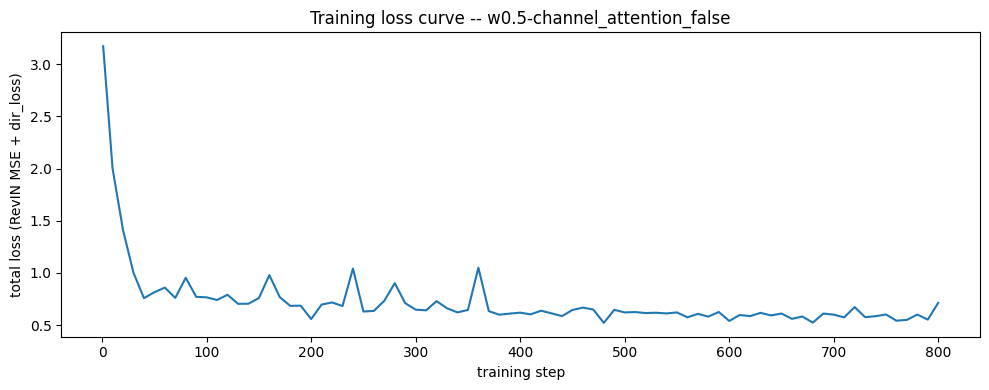

  OHLC MAE / RMSE     : 1.9723 / 3.2138
  volume MAE / RMSE   : 2,171,406.5 / 3,755,877.0
  dir acc per bar     : 0.4718 / 0.4677 / 0.4731
  coherence rate      : 0.8085
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w0.5-channel_attention_false.json

training w0.5-channel_attention_true
epoch  1/20  train_loss=1.549277 (mse=0.933561, dir=1.231432)  val_loss=4.831934 (mse=1.605223, dir=6.453422)
epoch  2/20  train_loss=0.849188 (mse=0.399859, dir=0.898659)  val_loss=1.081575 (mse=0.290499, dir=1.582151)
epoch  3/20  train_loss=0.783686 (mse=0.362141, dir=0.843091)  val_loss=1.112978 (mse=0.294261, dir=1.637434)
epoch  4/20  train_loss=0.742464 (mse=0.327818, dir=0.829292)  val_loss=1.158850 (mse=0.282821, dir=1.752059)
epoch  5/20  train_loss=0.752264 (mse=0.334325, dir=0.835877)  val_loss=0.893402 (mse=0.237903, dir=1.310998)
epoch  6/20  train_loss=0.699492 (mse=0.300003, dir=0.798977)  val_loss=0.943288 (mse=0.233159, dir=1.420257)
epoch  7/20  train_

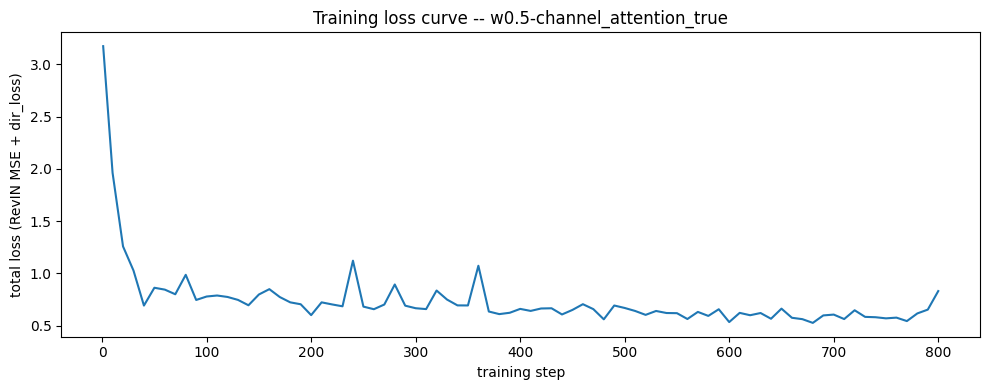

  OHLC MAE / RMSE     : 2.8210 / 4.0081
  volume MAE / RMSE   : 2,306,587.2 / 3,896,660.8
  dir acc per bar     : 0.4643 / 0.4610 / 0.4506
  coherence rate      : 0.9508
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w0.5-channel_attention_true.json

training w1.0-channel_attention_false
epoch  1/20  train_loss=2.352873 (mse=1.037740, dir=1.315134)  val_loss=6.988762 (mse=1.350486, dir=5.638276)
epoch  2/20  train_loss=1.335412 (mse=0.425644, dir=0.909768)  val_loss=3.109937 (mse=0.476018, dir=2.633919)
epoch  3/20  train_loss=1.230633 (mse=0.376117, dir=0.854517)  val_loss=1.743620 (mse=0.290063, dir=1.453557)
epoch  4/20  train_loss=1.145486 (mse=0.333043, dir=0.812443)  val_loss=1.508339 (mse=0.246921, dir=1.261418)
epoch  5/20  train_loss=1.140294 (mse=0.325758, dir=0.814536)  val_loss=2.405964 (mse=0.309419, dir=2.096545)
epoch  6/20  train_loss=1.099539 (mse=0.305719, dir=0.793821)  val_loss=1.348311 (mse=0.227569, dir=1.120742)
epoch  7/20  train_

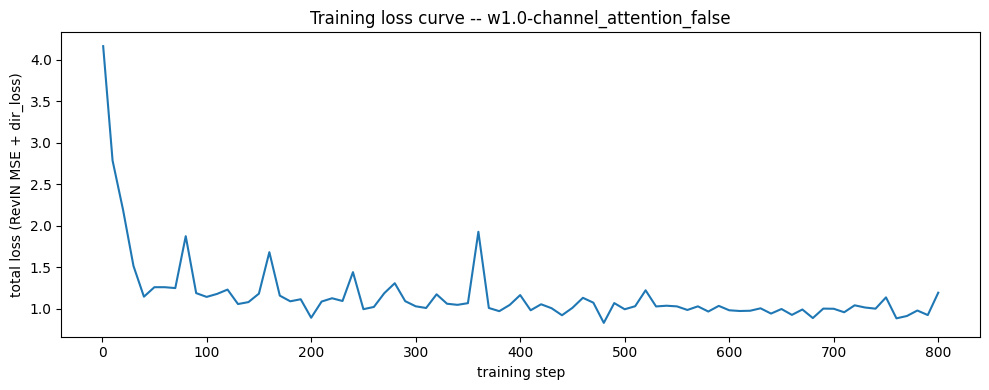

  OHLC MAE / RMSE     : 2.1221 / 3.3827
  volume MAE / RMSE   : 2,227,213.0 / 3,848,572.2
  dir acc per bar     : 0.4664 / 0.4581 / 0.4572
  coherence rate      : 0.8673
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w1.0-channel_attention_false.json

training w1.0-channel_attention_true
epoch  1/20  train_loss=2.275706 (mse=1.005936, dir=1.269770)  val_loss=7.941656 (mse=1.584648, dir=6.357008)
epoch  2/20  train_loss=1.356751 (mse=0.439688, dir=0.917063)  val_loss=2.505992 (mse=0.357810, dir=2.148182)
epoch  3/20  train_loss=1.232759 (mse=0.376886, dir=0.855873)  val_loss=2.227985 (mse=0.336874, dir=1.891111)
epoch  4/20  train_loss=1.171893 (mse=0.341789, dir=0.830104)  val_loss=1.606705 (mse=0.262967, dir=1.343738)
epoch  5/20  train_loss=1.191377 (mse=0.349912, dir=0.841466)  val_loss=1.514890 (mse=0.250108, dir=1.264782)
epoch  6/20  train_loss=1.116314 (mse=0.314320, dir=0.801994)  val_loss=1.535945 (mse=0.235455, dir=1.300490)
epoch  7/20  train_

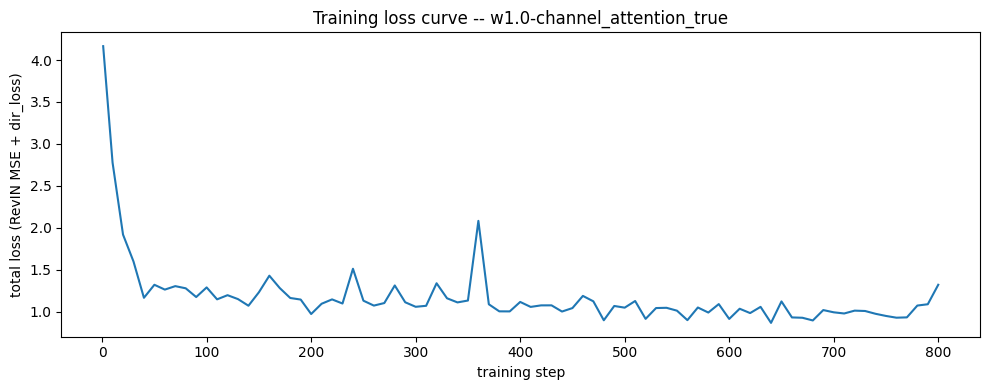

  OHLC MAE / RMSE     : 2.8505 / 4.0494
  volume MAE / RMSE   : 2,286,694.0 / 3,930,969.0
  dir acc per bar     : 0.4622 / 0.4606 / 0.4543
  coherence rate      : 0.9495
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w1.0-channel_attention_true.json

training w3.0-channel_attention_false
epoch  1/20  train_loss=5.170027 (mse=1.181770, dir=1.329419)  val_loss=19.344639 (mse=1.471146, dir=5.957831)
epoch  2/20  train_loss=3.369537 (mse=0.515205, dir=0.951444)  val_loss=5.726491 (mse=0.364248, dir=1.787414)
epoch  3/20  train_loss=2.964912 (mse=0.400244, dir=0.854889)  val_loss=5.987589 (mse=0.375565, dir=1.870675)
epoch  4/20  train_loss=2.850816 (mse=0.366798, dir=0.828006)  val_loss=5.062241 (mse=0.289326, dir=1.590972)
epoch  5/20  train_loss=2.896456 (mse=0.366428, dir=0.843343)  val_loss=7.908542 (mse=0.368231, dir=2.513437)
epoch  6/20  train_loss=2.736497 (mse=0.327176, dir=0.803107)  val_loss=4.131199 (mse=0.255850, dir=1.291783)
epoch  7/20  train

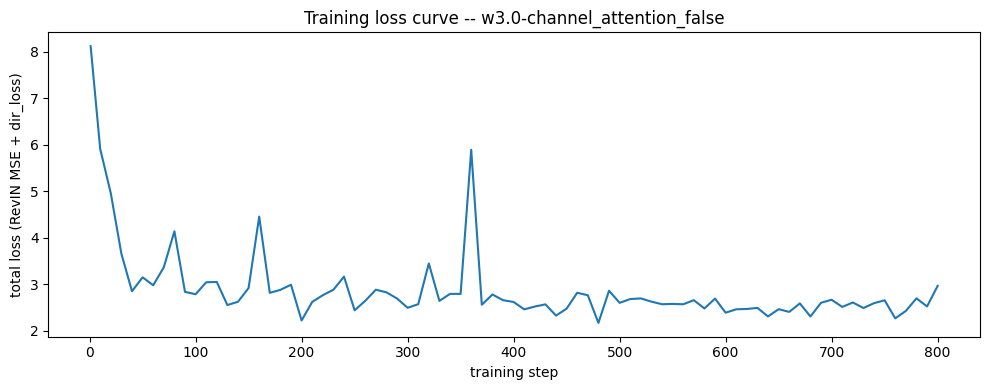

  OHLC MAE / RMSE     : 2.1070 / 3.3447
  volume MAE / RMSE   : 2,260,818.0 / 3,841,897.5
  dir acc per bar     : 0.4685 / 0.4698 / 0.4564
  coherence rate      : 0.8807
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w3.0-channel_attention_false.json

training w3.0-channel_attention_true
epoch  1/20  train_loss=5.114822 (mse=1.129670, dir=1.328384)  val_loss=21.652273 (mse=1.775928, dir=6.625448)
epoch  2/20  train_loss=3.366323 (mse=0.522192, dir=0.948044)  val_loss=5.419977 (mse=0.380942, dir=1.679678)
epoch  3/20  train_loss=3.071038 (mse=0.434305, dir=0.878911)  val_loss=6.680058 (mse=0.379610, dir=2.100149)
epoch  4/20  train_loss=2.936907 (mse=0.375245, dir=0.853887)  val_loss=6.638930 (mse=0.392875, dir=2.082018)
epoch  5/20  train_loss=2.985098 (mse=0.380330, dir=0.868256)  val_loss=4.613683 (mse=0.290939, dir=1.440915)
epoch  6/20  train_loss=2.717742 (mse=0.334399, dir=0.794448)  val_loss=4.529867 (mse=0.252617, dir=1.425750)
epoch  7/20  train

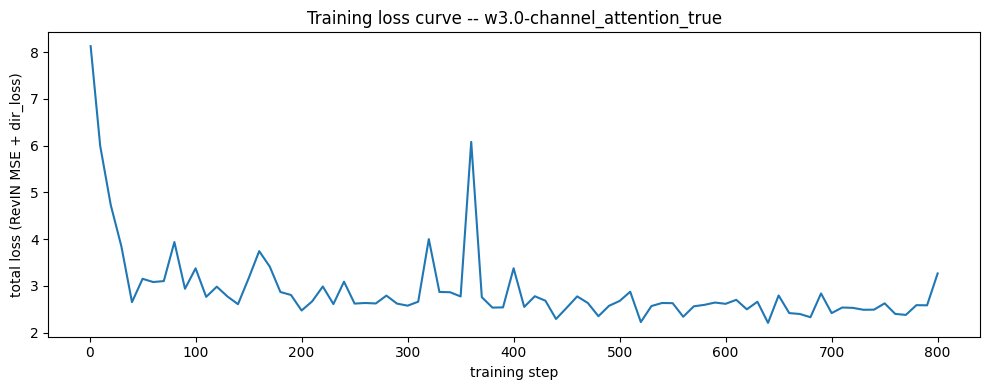

  OHLC MAE / RMSE     : 2.4163 / 3.7116
  volume MAE / RMSE   : 2,303,470.0 / 3,842,298.0
  dir acc per bar     : 0.4639 / 0.4568 / 0.4618
  coherence rate      : 0.8819
  wrote steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w3.0-channel_attention_true.json


done -- 6 runs completed.


In [8]:
def directional_loss(pred_close_real: torch.Tensor, true_close_real: torch.Tensor,
                      close_0: torch.Tensor, scale: float) -> torch.Tensor:
    """Soft, differentiable penalty for predicted/true close-return sign disagreement.
    pred_ret/true_ret are both measured relative to close_0 -- the same anchor
    directional_accuracy uses at eval time. pred_ret*true_ret > 0 (same sign) -> small
    loss; < 0 (opposite sign) -> large loss. `scale` rescales the product into the
    sigmoid's sensitive range before -log(sigmoid(.)) -- see intro markdown."""
    pred_ret = pred_close_real - close_0.unsqueeze(-1)
    true_ret = true_close_real - close_0.unsqueeze(-1)
    agreement = pred_ret * true_ret * scale
    return -F.logsigmoid(agreement).mean()


def run_epoch(model, loader, optimizer, device, dir_loss_weight: float, train: bool,
              loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, mse_total, dir_total, n = 0.0, 0.0, 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        future_values = batch['future_values'].to(device)

        with torch.set_grad_enabled(train):
            pred_norm = model(past_values)
            # RevIN.fit() was just called inside model() using this batch's context, so
            # model.revin.normalize() here uses the matching context-derived stats to put
            # the true OHLC target in the same normalized space the loss is computed in.
            # Volume's target is already log_volume_norm -- concatenated through unchanged.
            future_price_raw = future_values[:, :, :N_PRICE_CHANNELS]
            future_vol_norm = future_values[:, :, N_PRICE_CHANNELS:]
            true_norm = torch.cat([model.revin.normalize(future_price_raw), future_vol_norm], dim=-1)
            mse = F.mse_loss(pred_norm, true_norm)

            # Directional term, computed in real price space (see directional_loss above) --
            # denormalize only the price channels, no need to touch volume for this.
            pred_price_real = model.revin.denormalize(pred_norm[:, :, :N_PRICE_CHANNELS])
            pred_close_real = pred_price_real[:, :, CLOSE_IDX]
            true_close_real = future_price_raw[:, :, CLOSE_IDX]
            close_0 = past_values[:, -1, CLOSE_IDX]
            dir_loss = directional_loss(pred_close_real, true_close_real, close_0, DIR_LOSS_SCALE)

            loss = mse + dir_loss_weight * dir_loss

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = past_values.shape[0]
        total += loss.item() * bs
        mse_total += mse.item() * bs
        dir_total += dir_loss.item() * bs
        n += bs
    return {'loss': total / n, 'mse': mse_total / n, 'dir_loss': dir_total / n}


def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


def evaluate(model) -> dict:
    model.eval()
    all_true, all_pred, all_close0 = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            pv = batch['past_values'].to(DEVICE)
            fv = batch['future_values'].to(DEVICE)
            pred_norm = model(pv)
            pred_price = model.revin.denormalize(pred_norm[:, :, :N_PRICE_CHANNELS])
            pred_vol_norm = pred_norm[:, :, N_PRICE_CHANNELS:]
            pred_mixed = torch.cat([pred_price, pred_vol_norm], dim=-1)   # OHLC real, volume still log_volume_norm
            all_true.append(fv.cpu().numpy())
            all_pred.append(pred_mixed.cpu().numpy())
            all_close0.append(pv[:, -1, CLOSE_IDX].cpu().numpy())   # last context bar's real close

    true_raw = np.concatenate(all_true)     # (n, 3, 5) real OHLC + log_volume_norm
    pred_raw = np.concatenate(all_pred)     # (n, 3, 5) real OHLC (denormalized) + log_volume_norm
    close_0 = np.concatenate(all_close0)    # (n,)
    n = len(true_raw)

    true_ohlc = true_raw[:, :, :N_PRICE_CHANNELS]
    pred_ohlc = pred_raw[:, :, :N_PRICE_CHANNELS]
    ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

    # reconstruct_volume expects log_volume_norm -> real volume, same function/stats every
    # other notebook in this project uses -- no hand-rolled inverse needed here.
    true_vol = reconstruct_volume(true_raw[:, :, N_PRICE_CHANNELS], stats)
    pred_vol = reconstruct_volume(pred_raw[:, :, N_PRICE_CHANNELS], stats)
    vol_mae, vol_rmse = mae_rmse(pred_vol, true_vol)

    true_close_sign = np.sign(true_raw[:, :, CLOSE_IDX] - close_0[:, None])
    pred_close_sign = np.sign(pred_raw[:, :, CLOSE_IDX] - close_0[:, None])
    dir_acc = (true_close_sign == pred_close_sign).mean(axis=0)

    # Coherence check -- see markdown above.
    coherent_up = (pred_close_sign > 0).all(axis=1)
    coherent_down = (pred_close_sign < 0).all(axis=1)
    coherence_rate = float((coherent_up | coherent_down).mean())

    return {
        'n_windows': n,
        'ohlc_mae': ohlc_mae,
        'ohlc_rmse': ohlc_rmse,
        'volume_mae': vol_mae,
        'volume_rmse': vol_rmse,
        'directional_accuracy': dir_acc.tolist(),
        'coherence_rate': coherence_rate,
    }


os.makedirs('steven/comparison_metrics', exist_ok=True)
results = {}

for dir_loss_weight in DIR_LOSS_WEIGHTS:
    for channel_attention in CHANNEL_ATTENTION_SETTINGS:
        setting_key = f'w{dir_loss_weight}-channel_attention_{str(channel_attention).lower()}'
        print(f'\n{"="*70}\ntraining {setting_key}\n{"="*70}')

        # Reset the seed per combination so every one of the 6 runs gets identical weight
        # init/dropout draws -- data order is already independent of global RNG state
        # (np.random.default_rng(SEED+epoch) below), but model init/dropout use torch's
        # global RNG, which would otherwise keep advancing across the sweep.
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        model = build_model(channel_attention).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        loss_history = []
        step_holder = [0]
        best_val_loss = float('inf')

        for epoch in range(MAX_EPOCHS):
            train_rng = np.random.default_rng(SEED + epoch)
            n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
            train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
            train_ds = FixedContextRawDataset(raw, train_starts)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

            train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, dir_loss_weight, train=True,
                                       loss_history=loss_history, step_holder=step_holder)
            val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, dir_loss_weight, train=False)

            print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
                  f'train_loss={train_metrics["loss"]:.6f} (mse={train_metrics["mse"]:.6f}, dir={train_metrics["dir_loss"]:.6f})  '
                  f'val_loss={val_metrics["loss"]:.6f} (mse={val_metrics["mse"]:.6f}, dir={val_metrics["dir_loss"]:.6f})')

            if val_metrics['loss'] < best_val_loss:
                best_val_loss = val_metrics['loss']

        print(f'done ({setting_key}). best val_loss={best_val_loss:.6f}')

        fig, ax = plt.subplots(figsize=(10, 4))
        steps, losses = zip(*loss_history)
        ax.plot(steps, losses)
        ax.set_xlabel('training step')
        ax.set_ylabel('total loss (RevIN MSE + dir_loss)')
        ax.set_title(f'Training loss curve -- {setting_key}')
        plt.tight_layout()
        plt.show()

        eval_metrics = evaluate(model)
        print(f'  OHLC MAE / RMSE     : {eval_metrics["ohlc_mae"]:.4f} / {eval_metrics["ohlc_rmse"]:.4f}')
        print(f'  volume MAE / RMSE   : {eval_metrics["volume_mae"]:,.1f} / {eval_metrics["volume_rmse"]:,.1f}')
        dir_acc = eval_metrics['directional_accuracy']
        print(f'  dir acc per bar     : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')
        print(f'  coherence rate      : {eval_metrics["coherence_rate"]:.4f}')

        output = {
            'experiment': {
                **EXPERIMENT,
                'channel_attention': channel_attention,
                'dir_loss_weight': dir_loss_weight,
                'seed': SEED,
            },
            'best_val_loss': best_val_loss,
            **eval_metrics,
        }
        results[setting_key] = output

        out_path = f'steven/comparison_metrics/{EXPERIMENT["name"]}-{setting_key}.json'
        with open(out_path, 'w') as f:
            json.dump(output, f, indent=2)
        print(f'  wrote {out_path}')

print(f'\n\ndone -- {len(results)} runs completed.')


## Results summary

In [9]:
print(f'{"setting":<32} {"OHLC RMSE":>10} {"Vol RMSE":>14} {"dir acc (bar1/2/3)":>22} {"coherence":>10}')
for setting_key, r in results.items():
    da = r['directional_accuracy']
    print(f'{setting_key:<32} {r["ohlc_rmse"]:>10.4f} {r["volume_rmse"]:>14,.1f} '
          f'{da[0]:>6.4f}/{da[1]:.4f}/{da[2]:.4f}  {r["coherence_rate"]:>9.4f}')

print(f'\n  === For comparison: hf_patchtst_revin_ohlc_global_volume, no directional loss ===')
print('  channel_attention=False: OHLC RMSE 3.12, dir acc 0.478/0.475/0.480, coherence 0.811')
print('  channel_attention=True : OHLC RMSE 3.24, dir acc 0.475/0.477/0.464, coherence 0.809')
print(f'\n  === For comparison: hf_patchtst_revin_ohlc_global_volume_dirloss, weight=0.1 (first pass, null result) ===')
print('  channel_attention=False: OHLC RMSE 3.10, dir acc 0.482/0.479/0.470, coherence 0.720')
print('  channel_attention=True : OHLC RMSE 3.25, dir acc 0.467/0.475/0.468, coherence 0.812')


setting                           OHLC RMSE       Vol RMSE     dir acc (bar1/2/3)  coherence
w0.5-channel_attention_false         3.2138    3,755,877.0 0.4718/0.4677/0.4731     0.8085
w0.5-channel_attention_true          4.0081    3,896,660.8 0.4643/0.4610/0.4506     0.9508
w1.0-channel_attention_false         3.3827    3,848,572.2 0.4664/0.4581/0.4572     0.8673
w1.0-channel_attention_true          4.0494    3,930,969.0 0.4622/0.4606/0.4543     0.9495
w3.0-channel_attention_false         3.3447    3,841,897.5 0.4685/0.4698/0.4564     0.8807
w3.0-channel_attention_true          3.7116    3,842,298.0 0.4639/0.4568/0.4618     0.8819

  === For comparison: hf_patchtst_revin_ohlc_global_volume, no directional loss ===
  channel_attention=False: OHLC RMSE 3.12, dir acc 0.478/0.475/0.480, coherence 0.811
  channel_attention=True : OHLC RMSE 3.24, dir acc 0.475/0.477/0.464, coherence 0.809

  === For comparison: hf_patchtst_revin_ohlc_global_volume_dirloss, weight=0.1 (first pass, null result

## Caveats and recommended next steps

- **`DIR_LOSS_SCALE=1.0` stays fixed this round, not swept** -- if even the highest weight
  (3.0) shows no effect, `DIR_LOSS_SCALE` (which controls how sharply the sigmoid responds
  to a given return product) is the other knob worth trying before concluding the
  directional-loss approach doesn't work here at all -- a poorly-scaled product could sit
  in the sigmoid's flat tails regardless of how large `DIR_LOSS_WEIGHT` is.
- **6 training runs in one pass** -- meaningfully longer wall-clock time than every other
  notebook in this family (which trained 2 models per run, not 6). Expect roughly 3x the
  runtime of a single `channel_attention` sweep.
- **Read the OHLC RMSE / directional accuracy tradeoff together, not either alone** -- a
  higher weight that improves direction by sacrificing a lot of RMSE is a different (and
  less clearly good) outcome than one that improves direction for free.
- **If nothing in this sweep crosses back above 0.50 directional accuracy**, that's fairly
  strong evidence this specific mechanism (reweighting a sign-agreement term against MSE)
  doesn't rescue the volume-included variant, and `hf_patchtst_revin_no_volume` (already
  above-chance, no loss engineering needed) remains the better path forward.
- **One seed per combination.** Same seed reused across all 6 for comparability, not
  varied to check run-to-run variance -- a real risk given the null result at weight=0.1
  could partly be seed noise, not just weight-too-small.
- **No backtest yet** -- deferred until a target/volume/loss combination is picked.
- **`evaluate.py` does NOT support this checkpoint shape** -- this notebook computes its
  own metrics inline instead, same as every other notebook in this family.


## Commit + push results

Same pattern as `steven/colab_train.ipynb`'s own commit/push cells -- reused here so every
experiment notebook that runs on a fresh Colab VM handles git auth the same way.


In [10]:
# Fresh Colab VM has no git identity configured -- needed for `commit` to work at all.
# Only sets it for this local clone (no --global), harmless to commit/share.
!git -C {REPO_DIR} config user.email "woodychang891121@gmail.com"
!git -C {REPO_DIR} config user.name "WoodyChang21"

commit_msg = f"chore(model): log {EXPERIMENT['name']} comparison_metrics from this Colab run"

!git add steven/comparison_metrics
!git status
!git commit -m {commit_msg!r}


On branch patchtst_ohlcv_mse
Your branch is up to date with 'origin/patchtst_ohlcv_mse'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w0.5-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w0.5-channel_attention_true.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w1.0-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w1.0-channel_attention_true.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w3.0-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_ohlc_global_volume_dirloss-w3.0-channel_attention_true.json

[patchtst_ohlcv_mse f31252d] chore(model): log hf_patchtst_revin_ohlc_global_volume_dirloss comparison_metrics from this Colab 

In [11]:
import getpass

# Fresh Colab VM has no stored GitHub credentials, so a plain `git push` over HTTPS
# can't authenticate. Prompting interactively (getpass masks it, and it's never written
# into this notebook's saved source/outputs) instead of hardcoding a token in a cell --
# a hardcoded token would get committed into git history the moment this notebook is
# pushed, which is a real credential leak. Needs a GitHub Personal Access Token with
# `repo` scope: https://github.com/settings/tokens
token = getpass.getpass("GitHub Personal Access Token: ")
push_url = f"https://{token}@github.com/WoodyChang21/ECE1508_GenAI.git"
!git -C {REPO_DIR} push {push_url} {BRANCH}
del token, push_url  # don't leave it sitting in a notebook-visible variable longer than needed


Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 12 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 2.19 KiB | 2.19 MiB/s, done.
Total 10 (delta 8), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (8/8), completed with 3 local objects.
To https://github.com/WoodyChang21/ECE1508_GenAI.git
   05313de..f31252d  patchtst_ohlcv_mse -> patchtst_ohlcv_mse
